<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/Eid_Vacation_Practice_Advanced.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ucimlrepo

In [76]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing, load_diabetes, load_breast_cancer, load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from ucimlrepo import fetch_ucirepo
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Q1  The Income Trap

# DATASET Adult Income (Census Income)  
https://archive.ics.uci.edu/dataset/2/adult

### RESEARCH
### Read about what 'capital-gain' and 'capital-loss' represent in US income

## Theory
1. The 'capital-gain' column has ~91% of its values equal to exactly zero, with a
few extreme values reaching over $99,000. Is this an outlier problem or a
distributional problem? Justify your answer using the concept of the Normal
Distribution from class.
2. If you apply StandardScaler (Z-score normalization) to 'capital-gain', what
happens to the Z-scores of those extreme values? Why would a RobustScaler be
more appropriate here?  
3. Explain Winsorization. If you apply 5th–95th percentile Winsorization to
'hours-per-week', what are you assuming about the data-generating process, and
what are the risks?


##  Practical
4. Load the dataset (it uses '?' for missing values — handle this first). Perform
train-test split. Plot the distribution of 'capital-gain' using a KDE plot. Confirm
the extreme skew visually.
5. Apply Winsorization (clip at 5th–95th percentile) to 'capital-gain' on the training
set. Apply the SAME clipping bounds to the test set. Plot before/after KDE
plots.
6. Apply RobustScaler to 'hours-per-week' and 'capital-gain' . Compare the scaled
range with what StandardScaler would have produced. Which handles the
outliers better? Justify numerically.

#### THEORY

1. It's a distributional problem. A Normal Distribution assumes values spread symmetrically around a mean. Here, 91% are exactly 0 and a few go to $99000. This is a zero-inflated distribution, not a Normal one with outliers. The extreme values aren't errors they're real wealthy people's capital gains. It can't be fixed  with outlier removal.

2. StandardScaler computes Z = (x - mean) / std. Since 91% of values are 0 and a few are huge, the mean gets pulled up and the std gets inflated by those extremes. The Z-scores of the extreme values won't look as extreme as they should, and the Z-scores of the zeros will become oddly negative. RobustScaler uses median and IQR instead since the median of capital-gain is 0 (most people have 0), it's not affected by the extreme values at all.

3. Winsorization is a method in which instead of removing outliers, these are capped. If I apply 5th–95th percentile Winsorization to hours-per-week:
- Any value below the 5th percentile gets replaced with the 5th percentile value
- Any value above the 95th percentile gets replaced with the 95th percentile value.

Assumption I'm making:
Values beyond those percentiles are measurement errors or noise, not real data points.

Risks:

If those extreme values are real (someone genuinely works 90 hrs/week), it's distorting the truth
It must be computed the bounds on the training set only, then apply the same bounds to the test set otherwise it's leaking test data information

/tmp/ipykernel_1140/466455033.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X.replace('?', np.nan, inplace = True)


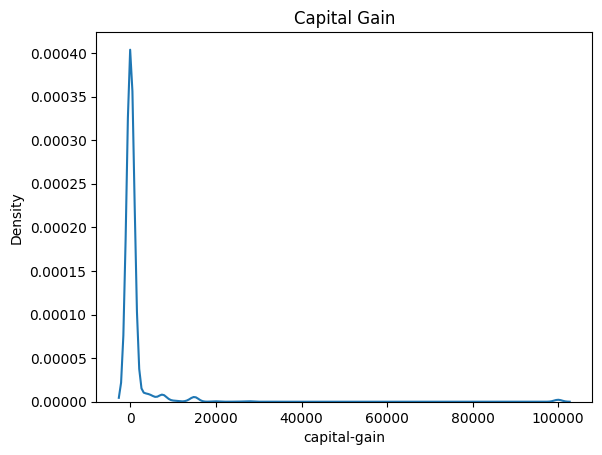

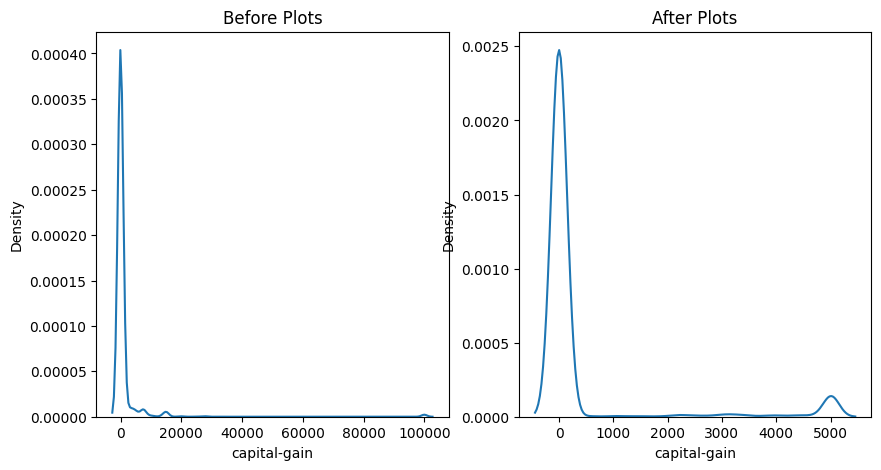

Robust Scaler: 
      hours-per-week  capital-gain
min            -7.8           0.0
max            11.8        5013.0
Standard Scaler: 
      hours-per-week  capital-gain
min       -3.179147     -0.290364
max        4.728217      3.807335


In [ ]:
# load dataset
adult = fetch_ucirepo(id=2)
X = adult.data.features
y = adult.data.targets

# handle missing value
X.replace('?', np.nan, inplace = True)

df_adult = pd.concat([X, y], axis = 1)

X = df_adult.drop('income', axis = 1)
y = df_adult['income']
# Perform train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#  Plot the distribution of 'capital-gain' using a KDE plot. Confirm the extreme skew visually.
sns.kdeplot(data = X_train, x = 'capital-gain')
plt.title('Capital Gain')
plt.show()

# Apply Winsorization (clip at 5th–95th percentile) to 'capital-gain' on the training set
X_train_original = X_train['capital-gain'].copy()
x = 5
x = x/100
min_range = X_train['capital-gain'].quantile(x)
max_range = X_train['capital-gain'].quantile(1 - x)

# Apply the SAME clipping bounds to the test set.
X_train['capital-gain'] = X_train['capital-gain'].clip(min_range, max_range)
X_test['capital-gain'] = X_test['capital-gain'].clip(min_range, max_range)

# Plot before/after KDE plots.
fig, axes = plt.subplots(1, 2, figsize = (10, 5))
sns.kdeplot(x = X_train_original, ax = axes[0]).set_title('Before Plots')
sns.kdeplot(data = X_train, x = 'capital-gain', ax = axes[1]).set_title('After Plots')
plt.show()

# Apply RobustScaler to 'hours-per-week' and 'capital-gain'
cols = ['hours-per-week', 'capital-gain']
rs = RobustScaler()
X_train_rs = pd.DataFrame(rs.fit_transform(X_train[cols]), columns = cols)
X_test_rs = pd.DataFrame(rs.transform(X_test[cols]), columns = cols)

ss = StandardScaler()
X_train_ss = pd.DataFrame(ss.fit_transform(X_train[cols]), columns = cols)
X_test_ss = pd.DataFrame(ss.transform(X_test[cols]), columns = cols)

print('Robust Scaler: \n', X_train_rs[cols].describe().loc[['min', 'max']])
print('Standard Scaler: \n', X_train_ss[cols].describe().loc[['min', 'max']])

# Q2  The Churning Machine

# DATASET
Telco Customer Churn   
https://www.kaggle.com/datasets/blastchar/telco-customer-churn

# RESEARCH
Research what 'churn' means in the telecom industry and why it is a
critical business KPI before starting.

# Theory
7. The target column 'Churn' has roughly 73% 'No' and 27% 'Yes'. Explain why
this class imbalance matters for a model. If you don't address it, what kind of
predictions might the model make?
8. The 'TotalCharges' column is stored as a string (object) despite being numeric.
What is the likely reason? (Hint: look at what happens with customers who have
0 tenure.) What preprocessing step is needed?
9. From an EDA perspective, what is the difference between a countplot with hue

# Practical
10. Load the dataset. Fix the 'TotalCharges' data type issue. Confirm by
checking df.info() before and after.
11. Perform full univariate analysis: (a) For all categorical columns, create
countplots; (b) For all numerical columns, plot histograms with kde=True. Write
at least one business insight per plot.
12. Perform multivariate analysis: (a) Create a countplot of 'Contract' vs 'Churn'
with hue; (b) Create a KDE plot of 'tenure' grouped by 'Churn';Describe two
findings that would help a business reduce churn.

# Theory
1. The imbalance matters for a model because when the model trains it becomes bias because of 73% No and only 27% Yes. If I don't address it the model will predict based on the higher percentage of value instead of scaling the data which should be meaningful.
2. TotalCharges stored as string:
Customers with 0 tenure (brand new, never billed) have a empty string in TotalCharges instead of 0. Pandas reads the whole column as object (string) because of these whitespace entries. The fix: replace " " with NaN, then pd.to_numeric(..., errors='coerce'), then fill or drop those NaN rows.
3. Standard Countplot Shows the total number of observations (frequency) for each category. On the other hand, countplot with hue Shows the distribution of a primary categorical variable but breaks down each bar into a secondary categorical variable using different colors

# Practical

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


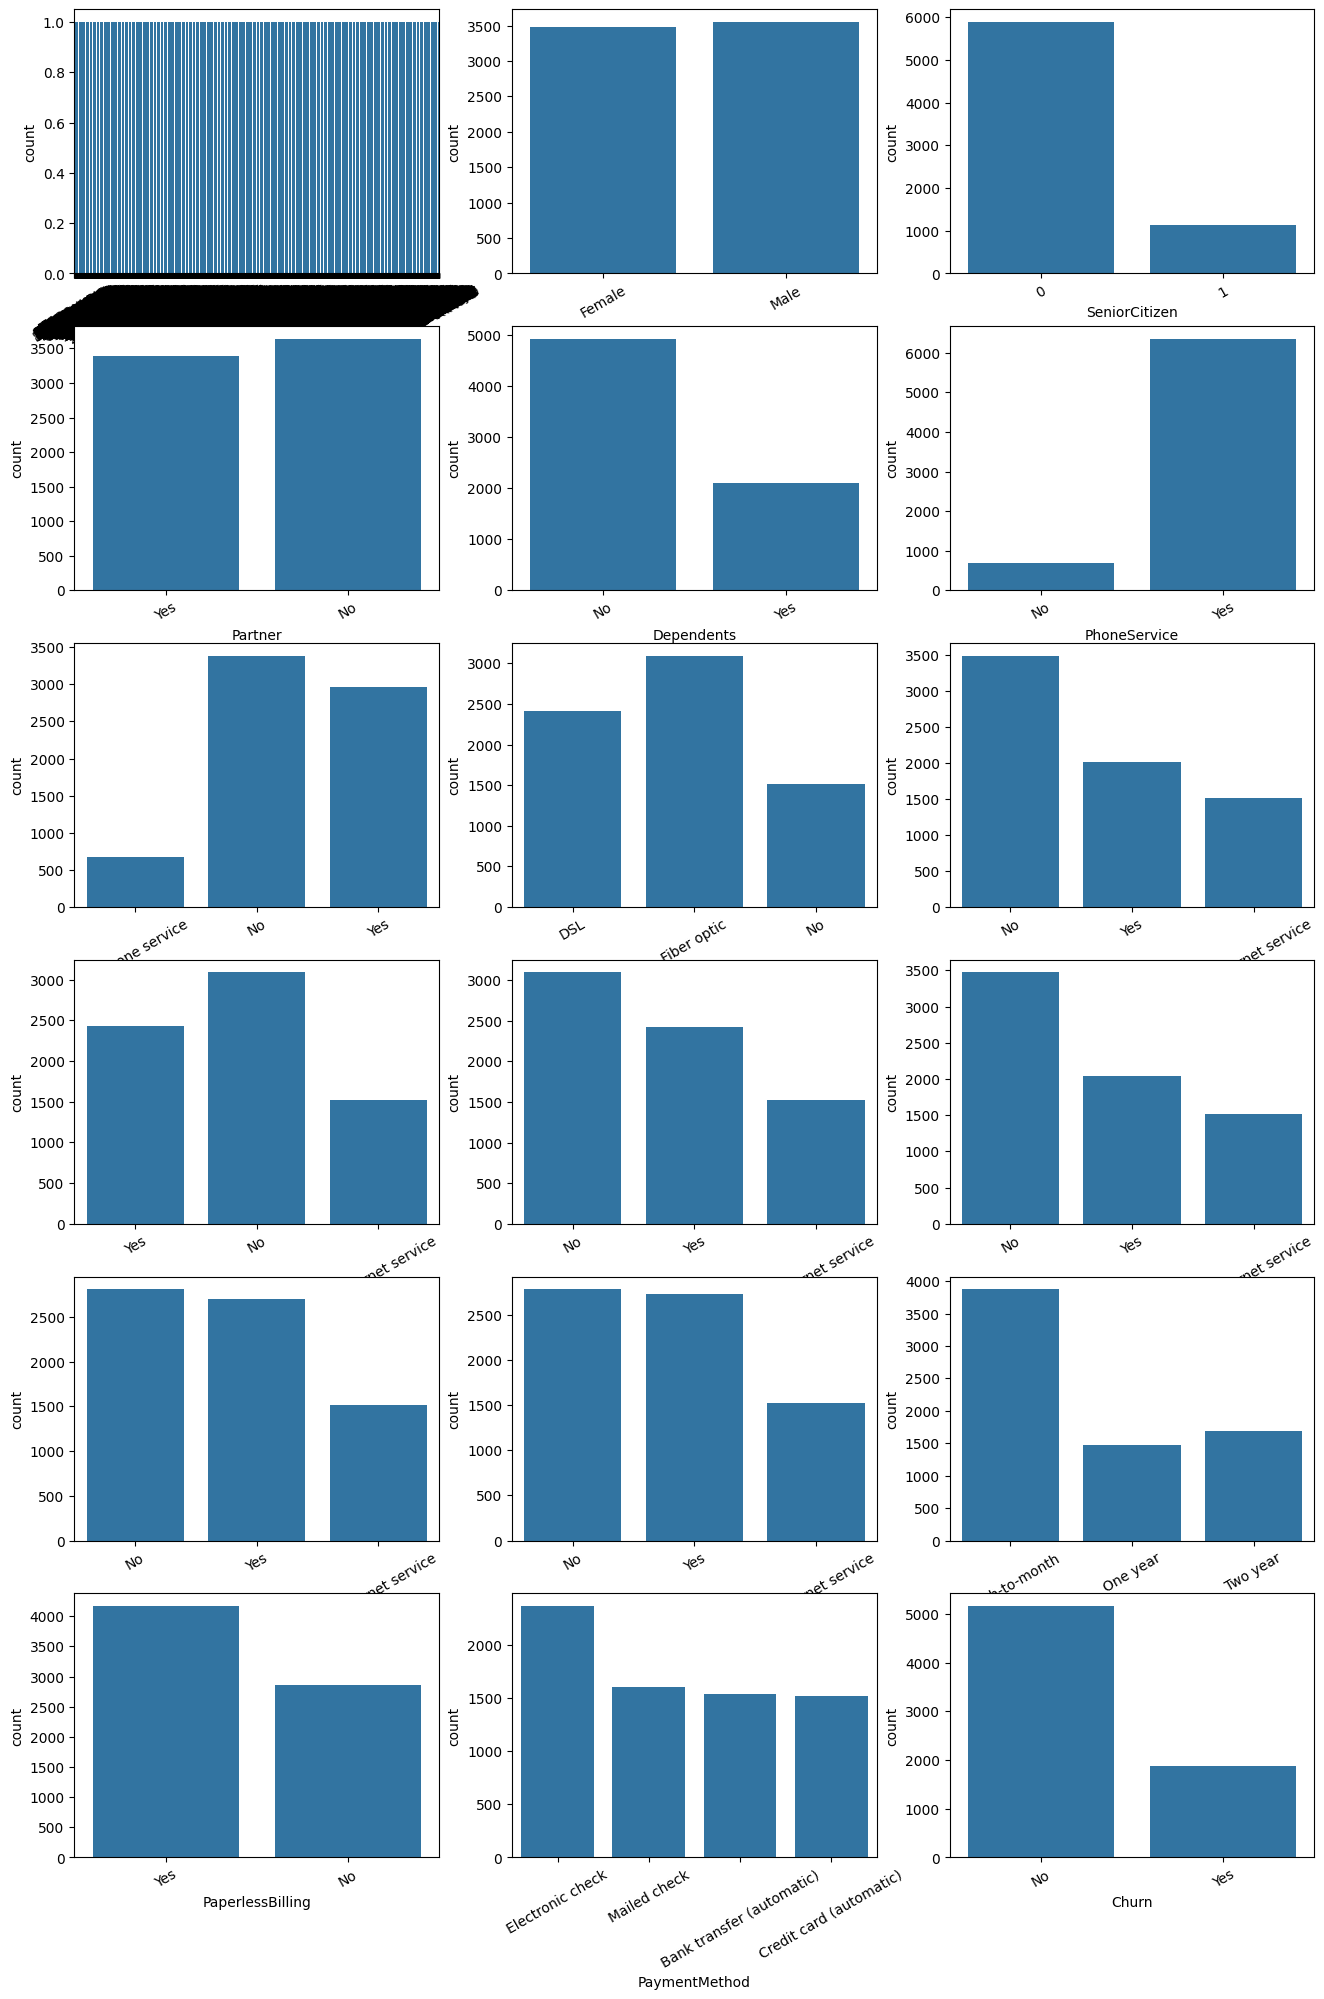

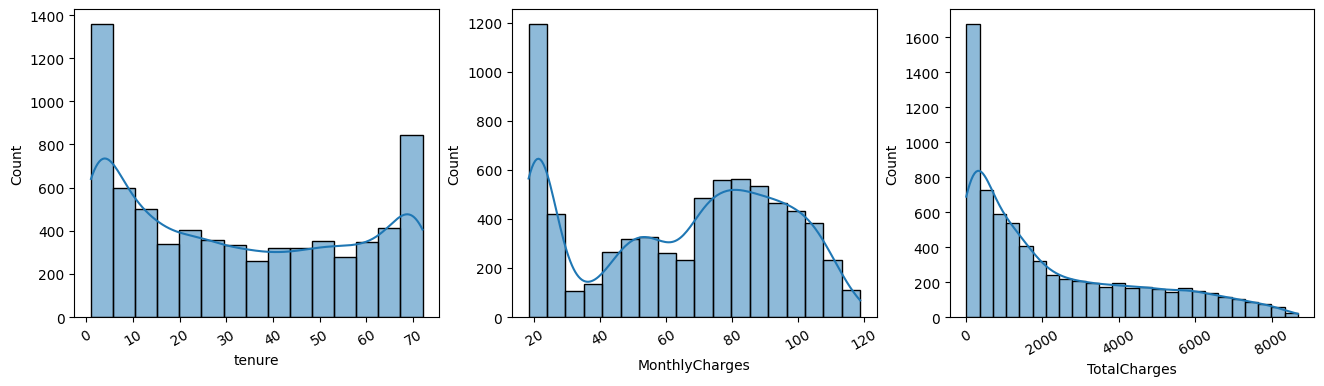

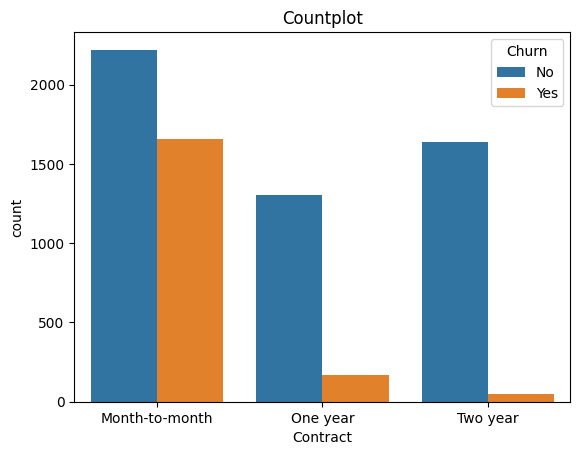

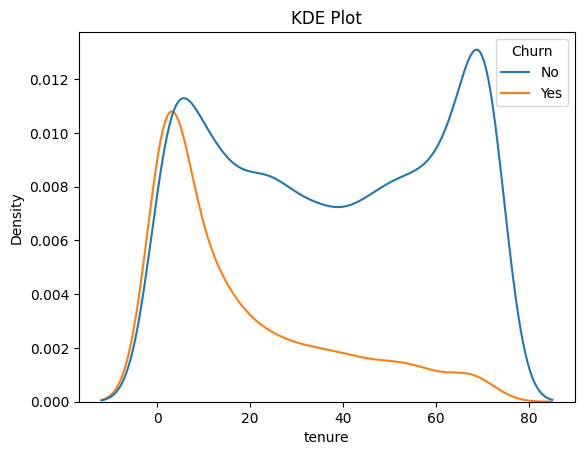

In [ ]:
# load dataset
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
# Before
print(df.info())

df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df.dropna(subset = ['TotalCharges'], inplace = True)

# After
print(df.info())

# Perform full univariate analysis:
# (a) For all categorical columns, create countplots
df_cat = df.drop(["tenure", "MonthlyCharges", "TotalCharges"], axis = 1)
df_num = df[["tenure", "MonthlyCharges", "TotalCharges"]]

fig, axes = plt.subplots(6, 3, figsize = (16, 24))
axes = axes.ravel()

for i, col in enumerate(df_cat):
  sns.countplot(data = df, x = col, ax = axes[i])
  axes[i].tick_params(axis='x', rotation=30)
plt.show()

# (b) For all numerical columns, plot histograms with kde=True.
fig, axes = plt.subplots(1, 3, figsize = (16, 4))
axes = axes.ravel()
for i, cols in enumerate(df_num):
  sns.histplot(data = df, x = cols, kde = True, ax = axes[i])
  axes[i].tick_params(axis='x', rotation=30)
plt.show()

# Perform multivariate analysis:
# (a) Create a countplot of 'Contract' vs 'Churn' with hue
sns.countplot(data = df, x = 'Contract', hue = 'Churn').set_title('Countplot')
plt.show()
# Finding 1: Customers on month-to-month contracts leave the most. Almost half of them churn (~43%). But customers who signed a 1 or 2 year contract barely leave (~3%).
# Business action: offer a discount or free add-on to move customers onto annual plans

# Create a KDE plot of 'tenure' grouped by 'Churn'
sns.kdeplot(data = df, x = 'tenure', hue = 'Churn').set_title('KDE Plot')
plt.show()
# Finding 2: Tenure means how many months a customer has been with the company. Customers who leave mostly do so within the first 12 months. Customers who stay longer than 2 years almost never leave.
# Business action: Focus retention efforts on new customers. Send them welcome offers, check-in calls, and loyalty rewards at month 1, 3, and 6. If you can keep them happy through the first year, they will most likely stay forever.

# Q3  Z-Scores & The Empirical Rule in the Wild   

# DATASET
Medical Cost Personal Dataset  
https://www.kaggle.com/datasets/mirichoi0218/insurance

# RESEARCH
Research what BMI (Body Mass Index) is, what the clinical thresholds are
(underweight, normal, overweight, obese), and why it might be a critical
feature for insurance charges.

#  Theory
13. According to the Empirical Rule (68-95-99.7), if BMI is approximately
normally distributed with mean=30 and std=6, what percentage of people have
BMI above 42?  

14. You detect that the 'charges' column has a Z-score outlier threshold at |Z| > 3. A student removes ALL rows with |Z| > 3 before the train-test split. Identify two problems with this approach.

15. Why might the IQR method detect different outliers than the Z-score
method on the same column? In which situation is each method preferred?

# Practical
16. Load the dataset. Verify whether 'bmi' follows an approximately normal
distribution: (a) Plot a KDE plot; (b) Compute skewness   
17. For the 'charges' column: (a) Identify outliers using the IQR method  (b)
Identify outliers using the Z-score method (c) Compare how many outliers each
method detects. Which is more conservative?
18. Create a new feature 'bmi_category' using the WHO thresholds
(Underweight < 18.5, Normal 18.5–24.9, Overweight 25–29.9, Obese >= 30).
Then use a barplot to visualize average 'charges' per BMI category. What pattern
do you see?

# Theory
1. The mean = 30 and std = 6, so according to the empirical rule, (42 - 30) / 6 = 2 percentage of people fall between bellow the mean 30 - (2 x 6) = 18 and above the mean 30 + (2 x 6) = 42. So it can be said that, around 2 percentages of people have BMI above 42.
2. - First Problem: As the student removed the rows before train test split the test model can get the data context first which leads to data leakage.
    - Second Problem: The model will recieve extreme value if not trained properly because it will never know how to handle the unrealistic data.
3. - Z-score assumes data is normally distributed. It flags values far from the mean. If data is skewed, the mean itself is pulled by extremes, so Z-score misses some outliers.
   - IQR uses the middle 50% of data (Q1 to Q3). It doesn't care about the mean at all, so it works better on skewed data.
   - The z score method is used when the data is roughly normally distributed and IQR when the data is skewed

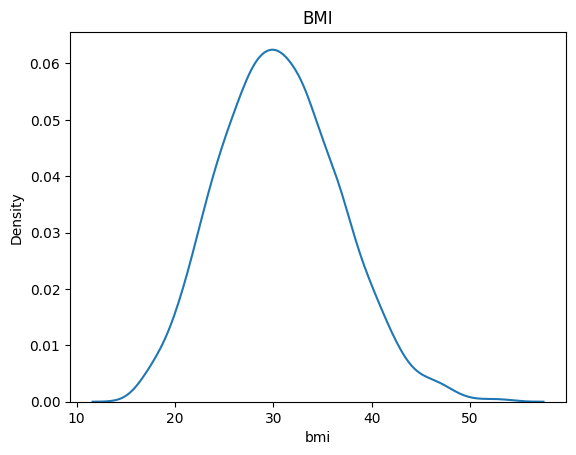

Skewness: 0.2840471105987448
IQR Outlier: 139
Z score Outlier: 7


Text(0.5, 1.0, 'Charges vs bmi category')

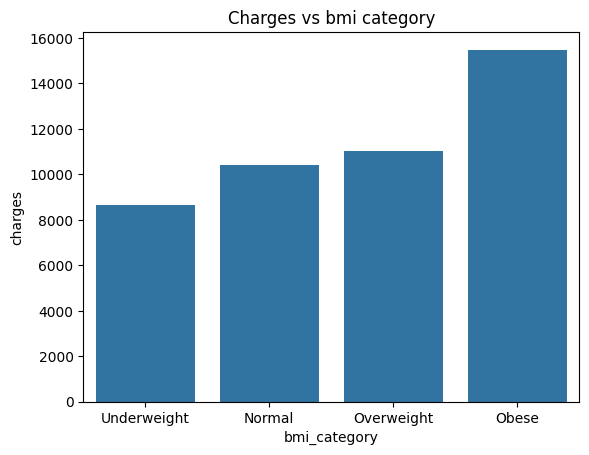

In [ ]:
# Load the dataset.
insurance = pd.read_csv('insurance.csv')
insurance

# Verify whether 'bmi' follows an approximately normal distribution:
# (a) Plot a KDE plot
sns.kdeplot(data = insurance, x = 'bmi').set_title('BMI')
plt.show()

# (b) Compute skewness
skewed_bmi = insurance['bmi'].skew()
print('Skewness:', skewed_bmi)

# For the 'charges' column:
# (a) Identify outliers using the IQR method
Q1 = insurance['charges'].quantile(0.25)
Q3 = insurance['charges'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
iqr_outlier = insurance[(insurance['charges'] < lower_bound) | (insurance['charges'] > upper_bound)]
print('IQR Outlier:', len(iqr_outlier))

# (b) Identify outliers using the Z-score method
mean = insurance['charges'].mean()
std = insurance['charges'].std()
insurance['Z_Score_Outlier'] = (insurance['charges'] - mean) / std
Z_score_outlier = insurance[abs(insurance['Z_Score_Outlier']) > 3]
print('Z score Outlier:', len(Z_score_outlier))

# (c) Compare how many outliers each method detects. Which is more conservative?
# IQR detects: 139 outliers and Z Score detects: 7 outliers. So IQR is more conservative.

# Create a new feature 'bmi_category' using the WHO thresholds (Underweight < 18.5, Normal 18.5–24.9, Overweight 25–29.9, Obese >= 30).
insurance['bmi_category'] = pd.cut(insurance['bmi'], bins = [0, 18.5, 24.9, 29.9, 100], labels = ['Underweight', 'Normal', 'Overweight', 'Obese'])

# Then use a barplot to visualize average 'charges' per BMI category. What pattern do you see?
sns.barplot(data = insurance, x = 'bmi_category', y = 'charges', errorbar = None).set_title('Charges vs bmi category')
# Ans: From the barplot I can see that the obese customers pay highest insurance charges than other customers.

# Q4  The Big City Problem — Outlier Handling at Scale    

# DATASET
NYC Taxi Trip Duration   
https://www.kaggle.com/c/nyc-taxi-trip-duration   
use train.csv, with 10 or 20k data

# RESEARCH
Research the geography of New York City's boroughs. Understand the
maximum realistic trip duration and distance in NYC. This is essential to
define what constitutes a real outlier.

# Theory
19. A trip duration of 86,400 seconds (24 hours) exists in this dataset. Is this a
data entry error, a real event, or something else? How would you decide
programmatically AND using domain knowledge?
20. After removing outliers from the training set, should you also remove
outliers from the test set? Justify your answer carefully — think about what a
test set represents in a real production scenario.

# Practical
21. Load the dataset (sample 20k rows). Convert 'pickup_datetime' to datetime
and extract hour, day-of-week, and month as new features. Check: are there any
biologically impossible trip durations (e.g., <= 0 seconds or > 24 hours)?
22. Apply IQR-based outlier detection to 'trip_duration'. Print how many
outliers were detected and what % of the data they represent. Remove them
from the training set ONLY.
23. Create a scatter plot of pickup_longitude vs pickup_latitude, coloring points
by trip_duration. Do the outlier trips cluster in any particular geographic area?
What does that suggest?

# Theory
1. 86,400 seconds (24 hour trip)
This could be a data entry error (someone forgot to end the trip) or a real edge case (taxi left running overnight). To decide:
     - Domain knowledge: A normal NYC taxi trip is 5–30 minutes. 24 hours is impossible for a normal ride.
     - Programmatically: Flag any trip above a threshold like 3–4 hours (10,800 seconds) as an outlier. 24 hours is clearly beyond any realistic NYC trip.

2. The test set should be untouched because if the outliers are removed from the test set, the model would face unrealistic extreme values in real life which will lead to a false or bad result.

# Practical

Impossible trip duration: 0
trip outliers: 955
Outliers %: 4.78%
df after cleaning: 19045


Text(0.5, 1.0, 'pickup_longitude vs pickup_latitude')

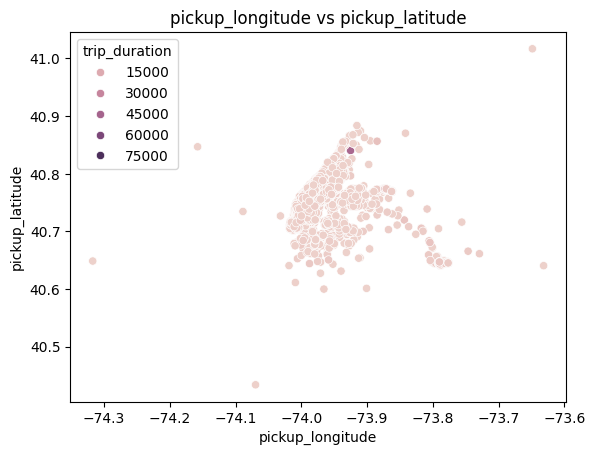

In [ ]:
# Load the dataset (sample 20k rows).
train_df = pd.read_csv('train.csv').sample(20000, random_state = 42)

# Convert 'pickup_datetime' to datetime and extract hour, day-of-week, and month as new features
train_df['pickup_datetime'] = pd.to_datetime(train_df['pickup_datetime'])

train_df['hour'] = train_df['pickup_datetime'].dt.hour
train_df['day-of-week'] = train_df['pickup_datetime'].dt.dayofweek
train_df['month'] = train_df['pickup_datetime'].dt.month

# Check: are there any biologically impossible trip durations (e.g., <= 0 seconds or > 24 hours)?
check_impossible = train_df[(train_df['trip_duration'] <= 0) | (train_df['trip_duration'] > 86400)]
print('Impossible trip duration:', len(check_impossible))

# Apply IQR-based outlier detection to 'trip_duration'
q1 = train_df['trip_duration'].quantile(0.25)
q3 = train_df['trip_duration'].quantile(0.75)
iqr = q3-q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
trip_outlier = train_df[(train_df['trip_duration'] < lower) | (train_df['trip_duration'] > upper)]

# Print how many outliers were detected and what % of the data they represent.
print('trip outliers:', len(trip_outlier))
print(f"Outliers %: {100 * len(trip_outlier) / len(train_df):.2f}%")

# Remove them from the training set ONLY.
clean_train = train_df[(train_df['trip_duration'] >= lower) & (train_df['trip_duration'] <= upper)]
print('df after cleaning:', len(clean_train))

# Create a scatter plot of pickup_longitude vs pickup_latitude, coloring points by trip_duration
sns.scatterplot(data = train_df, x = 'pickup_longitude', y = 'pickup_latitude', hue = 'trip_duration').set_title('pickup_longitude vs pickup_latitude')

# Do the outlier trips cluster in any particular geographic area? What does that suggest?
# Outlier trips (very long durations shown in dark red) tend to cluster outside the main NYC area — suggesting GPS errors or trips to airports

# Q5  Happiness by the Numbers — Full EDA Story  

# DATASET
World Happiness Report 2023  |  Kaggle:
https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2

# RESEARCH
Read the executive summary of the World Happiness Report methodology
(available on worldhappiness.report). Understand what the 'Ladder score',

# Theory
1. The 'Logged GDP per capita' column already has a log transformation applied. Why might the original GDP per capita have been log-transformed before inclusion in this report? What distribution property does log-transformation fix? ( Optional : Haven’t covered in the module , you can study it by yourself. We will cover it if it seems necessary )
2. You are asked to predict a country's happiness score. You have 'Social support', 'Healthy life expectancy', and 'Freedom to make life choices' as features. Explain conceptually whether you expect these will impact a man happiness score
3. A student concludes from a scatterplot that 'high GDP causes high happiness'. Critique this conclusion. Explain your thoughts

# Practical
1. Load the dataset. Identify the top 10 and bottom 10 happiest countries. Create
a horizontal bar chart showing both groups side-by-side with different colors.
2. Create a scatterplot of 'Logged GDP per capita' vs 'Ladder score'. Add a
regression line using sns.regplot().  
3. Perform regional analysis: group by 'Regional indicator' and compute the
mean of all numeric columns. Visualize mean happiness by region using a barplot
sorted by score. Which region has the highest variance in happiness? Use a boxplot

# Theory
1. Raw GDP per capita is heavily right-skewed, a few very rich countries have extremely high values. Log transformation compresses those extreme values and makes the distribution more normal and easier to work with in models.
2. These three things directly affect how good a person feels about their life. A country where people feel supported, live long healthy lives, and can make their own choices will naturally report higher happiness. These are not random variables, they have a direct human connection to wellbeing.
3. This is correlation, not causation. Without any doubt that the richer countries tend to be happier on a scatterplot but GDP does not directly cause happiness. Rich countries also tend to have better healthcare, stronger institutions, more freedom, and better social support. Any of those could be the real cause. it can't be concluded causation from a scatterplot alone.

# Practical

Top 10: 
   Country name  Ladder score
0      Finland         7.842
1      Denmark         7.620
2  Switzerland         7.571
3      Iceland         7.554
4  Netherlands         7.464
5       Norway         7.392
6       Sweden         7.363
7   Luxembourg         7.324
8  New Zealand         7.277
9      Austria         7.268

Bottom 10: 
     Country name  Ladder score
148  Afghanistan         2.523
147     Zimbabwe         3.145
146       Rwanda         3.415
145     Botswana         3.467
144      Lesotho         3.512
143       Malawi         3.600
142        Haiti         3.615
141     Tanzania         3.623
140        Yemen         3.658
139      Burundi         3.775


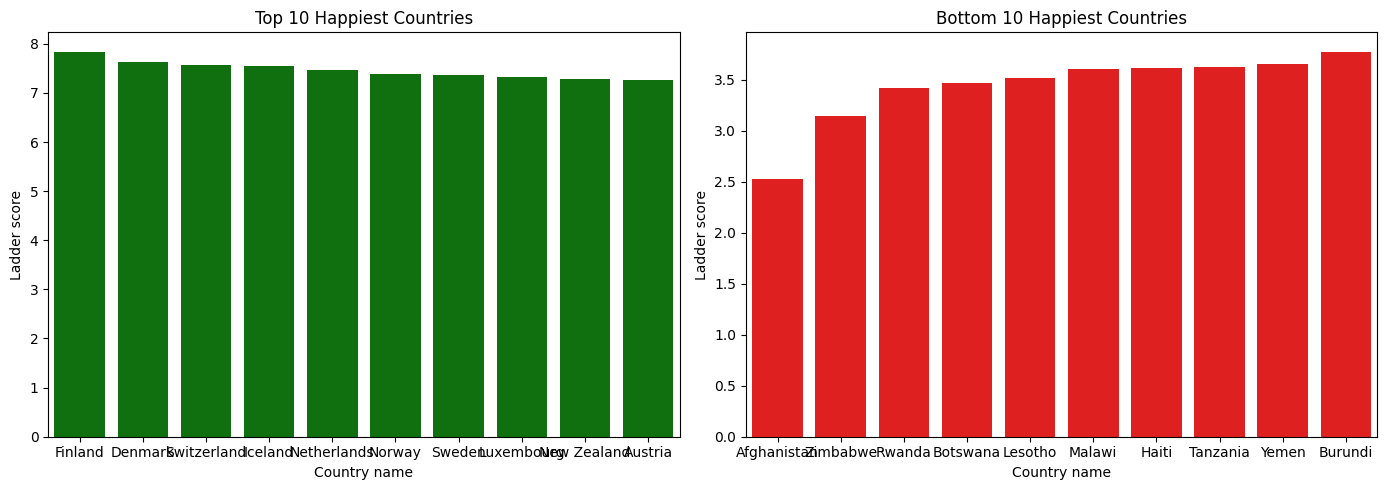

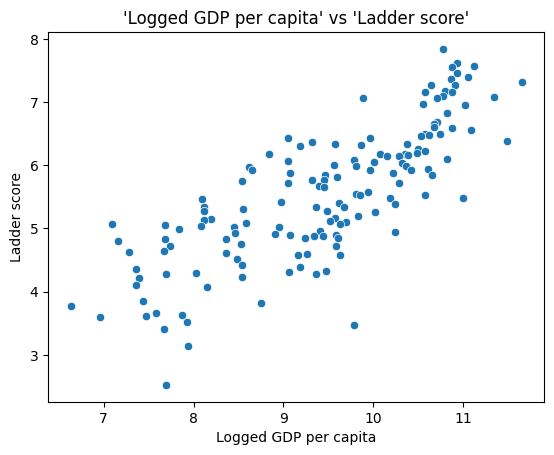

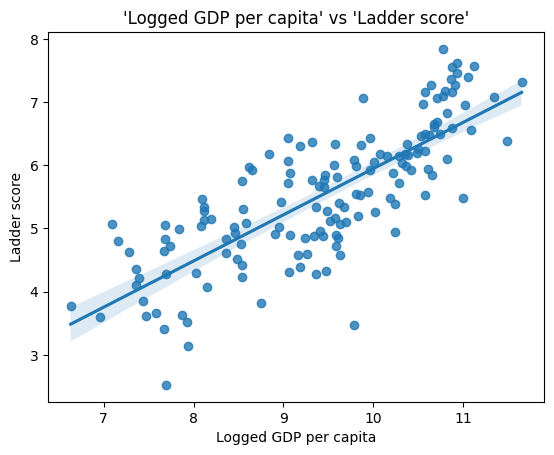

                   Regional indicator  Ladder score
0               North America and ANZ      7.128500
1                      Western Europe      6.914905
2          Central and Eastern Europe      5.984765
3         Latin America and Caribbean      5.908050
4                           East Asia      5.810333
5  Commonwealth of Independent States      5.467000
6                      Southeast Asia      5.407556
7        Middle East and North Africa      5.219765
8                  Sub-Saharan Africa      4.494472
9                          South Asia      4.441857


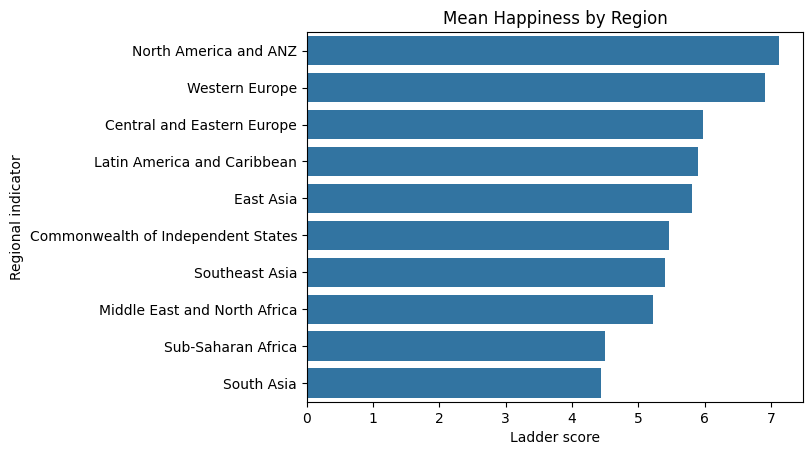

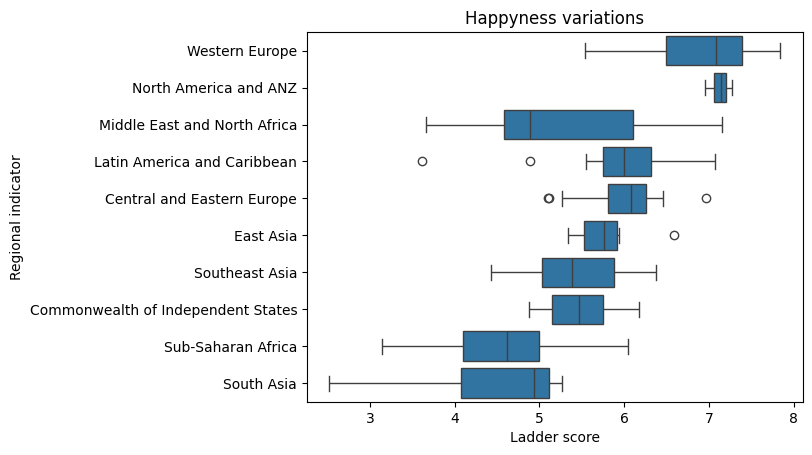

In [ ]:
# Load the dataset
world_happy_df = pd.read_csv('world-happiness-report-2021.csv')

# Identify the top 10 and bottom 10 happiest countries
top_10_happy = world_happy_df.nlargest(10, 'Ladder score')[['Country name', 'Ladder score']]
bottom_10_happy = world_happy_df.nsmallest(10, 'Ladder score')[['Country name', 'Ladder score']]
print('Top 10: \n', top_10_happy)
print()
print('Bottom 10: \n', bottom_10_happy)

# Create a horizontal bar chart showing both groups side-by-side with different colors.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes = axes.ravel()
sns.barplot(data = top_10_happy, x = 'Country name', y = 'Ladder score', color = 'green', ax = axes[0])
axes[0].set_title('Top 10 Happiest Countries')

sns.barplot(data = bottom_10_happy, x = 'Country name', y = 'Ladder score', color = 'red', ax = axes[1])
axes[1].set_title('Bottom 10 Happiest Countries')
plt.tight_layout()
plt.show()

# Create a scatterplot of 'Logged GDP per capita' vs 'Ladder score'. Add a regression line using sns.regplot().
sns.scatterplot(data = world_happy_df, x = 'Logged GDP per capita', y = 'Ladder score').set_title("'Logged GDP per capita' vs 'Ladder score'")
plt.show()

sns.regplot(data = world_happy_df, x = 'Logged GDP per capita', y = 'Ladder score').set_title("'Logged GDP per capita' vs 'Ladder score'")
plt.show()

# Perform regional analysis: group by 'Regional indicator' and compute the mean of all numeric columns
region_mean = world_happy_df.groupby('Regional indicator')['Ladder score'].mean().sort_values(ascending=False).reset_index()
print(region_mean)

# Visualize mean happiness by region using a barplot sorted by score.
sns.barplot(data = region_mean, x = 'Ladder score', y = 'Regional indicator').set_title('Mean Happiness by Region')
plt.show()

# Which region has the highest variance in happiness? Use a boxplot
sns.boxplot(data = world_happy_df, x = 'Ladder score', y = 'Regional indicator').set_title('Happyness variations')
plt.show()

# SURPRISE BONUS CHALLENGE  
### The End-to-End Pipeline Challenge

Pick ANY one of the 5 datasets above. Build a complete, end-to-end sklearn
ColumnTransformer that:
- Handles missing values with the correct strategy for each column type
- Encodes all categorical features appropriately for the model
- Applies the right scaler (Standard vs. Robust — justify your choice)
- Handles outliers using either Zscore ,  IQR clipping or Winsorization (before
the pipeline)


In [78]:
# Load dataset
telco_df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
telco_df.drop(columns=['customerID'], inplace=True)

# Fix TotalCharges
telco_df['TotalCharges'] = telco_df['TotalCharges'].replace(' ', np.nan)
telco_df['TotalCharges'] = pd.to_numeric(telco_df['TotalCharges'], errors='coerce')

# Split
X = telco_df.drop(columns=['Churn'])
y = telco_df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# IQR clipping BEFORE pipeline — on train only, apply same bounds to test
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in num_cols:
    num_q1    = X_train[col].quantile(0.25)
    num_q3    = X_train[col].quantile(0.75)
    num_iqr   = num_q3 - num_q1
    num_lower = num_q1 - 1.5 * num_iqr
    num_upper = num_q3 + 1.5 * num_iqr
    X_train[col] = X_train[col].clip(num_lower, num_upper)
    X_test[col]  = X_test[col].clip(num_lower, num_upper)

# Column groups
cat_cols = X.select_dtypes(include='object').columns.tolist()

# ColumnTransformer
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

preprocessor.set_output(transform='pandas')
preprocessor.fit(X_train)
X_train = preprocessor.transform(X_train)
X_test  = preprocessor.transform(X_test)

print(X_train.head())
print("Shape:", X_train.shape)

        tenure  MonthlyCharges  TotalCharges  gender  Partner  Dependents  \
2142 -0.173913       -0.104729     -0.021801     0.0      0.0         1.0   
1623  0.543478        0.492272      1.095525     0.0      0.0         0.0   
6074 -0.608696       -0.868743     -0.408717     1.0      1.0         0.0   
1362 -0.543478       -0.005998     -0.345525     1.0      0.0         0.0   
6754 -0.630435       -0.159170      0.000000     1.0      0.0         1.0   

      PhoneService  MultipleLines  InternetService  OnlineSecurity  \
2142           1.0            0.0              0.0             2.0   
1623           1.0            2.0              1.0             0.0   
6074           0.0            1.0              0.0             0.0   
1362           1.0            0.0              1.0             0.0   
6754           1.0            2.0              0.0             2.0   

      OnlineBackup  DeviceProtection  TechSupport  StreamingTV  \
2142           0.0               2.0          0.0 